In [1]:
import os
import pandas as pd

def txt_dir_to_df(input_dir):
    records = []

    for filename in os.listdir(input_dir):
        if not filename.endswith(".txt"):
            continue
        
        path = os.path.join(input_dir, filename)
        
        with open(path, "r") as f:
            for line in f:
                seq = line.strip()
                if seq:
                    records.append({"filename": filename, "cdr3": seq})
    
    return pd.DataFrame(records)


# Example
input_dir = "/scratch/project/tcr_ml/tcr_synapse/gliphed/t1d_cdr3"
df = txt_dir_to_df(input_dir)
print(df.head())
print(df.shape)


                                  filename             cdr3
0  part_table_BFI-0010756_cdr3_cluster.txt  CASSLGRNADTGELF
1  part_table_BFI-0010756_cdr3_cluster.txt    CASSYSGRNAEAF
2  part_table_BFI-0010756_cdr3_cluster.txt   CSARGRNANTGELF
3  part_table_BFI-0010756_cdr3_cluster.txt  CASSYDGGGMYNEQF
4  part_table_BFI-0010756_cdr3_cluster.txt     CASSYDGGTQAF
(21960, 2)


In [38]:
control_df = pd.read_csv("/scratch/project/tcr_ml/gnn_release/t1d_imgt_sample_scores.csv")

control_df

,source,sequence,scores
0,part_table_BFI-0010663.pt,CASSFRTLNTGELF,0.913719
1,part_table_BFI-0010663.pt,CASSVAPDMNTEAF,0.070657
2,part_table_BFI-0010663.pt,CASSPLDRGQTEAF,0.000817
3,part_table_BFI-0010663.pt,CASSLLAGGSNEQF,0.798384
4,part_table_BFI-0010663.pt,CATSEGPMNTEAF,0.158882
...,...,...,...
764207,part_table_BFI-0010690.pt,CASSLSGAGGYNEQF,0.947814
764208,part_table_BFI-0010690.pt,CASSLITMNTGELF,0.587595
764209,part_table_BFI-0010690.pt,CASVRGMGTEAF,0.031150
764210,part_table_BFI-0010690.pt,CASAGQGNTGELF,0.290325


In [25]:
cancer_df = pd.read_csv("/scratch/project/tcr_ml/gnn_release/aml_zero_sample_scores.csv")
cancer_df

,source,sequence,scores
0,01-0051_409375_T_R_22HM3TLT3_TCAGAAGGCG-GGCCAT...,CSVDSTGELGYTF,0.614030
1,01-0051_409375_T_R_22HM3TLT3_TCAGAAGGCG-GGCCAT...,CSVEGQEVDYGYTF,0.692437
2,01-0051_409375_T_R_22HM3TLT3_TCAGAAGGCG-GGCCAT...,CASSLTPGNTGELFF,0.835157
3,01-0051_409375_T_R_22HM3TLT3_TCAGAAGGCG-GGCCAT...,CASSLGDRGPYSNQPQHF,0.633156
4,01-0051_409375_T_R_22HM3TLT3_TCAGAAGGCG-GGCCAT...,CASSLGGGHGNRYTF,0.072496
...,...,...,...
13395,P021501_381133_T_R_HWWC5DSX5_CTCTGCAGCG-TACATC...,CSVSFAGHPRTDTQYF,0.863095
13396,P021501_381133_T_R_HWWC5DSX5_CTCTGCAGCG-TACATC...,CSASPPTGLNTEAFF,0.687903
13397,P021501_381133_T_R_HWWC5DSX5_CTCTGCAGCG-TACATC...,CSASPPTGLNTEAFF,0.687903
13398,P021501_381133_T_R_HWWC5DSX5_CTCTGCAGCG-TACATC...,CSAGQRMGEQFF,0.934600


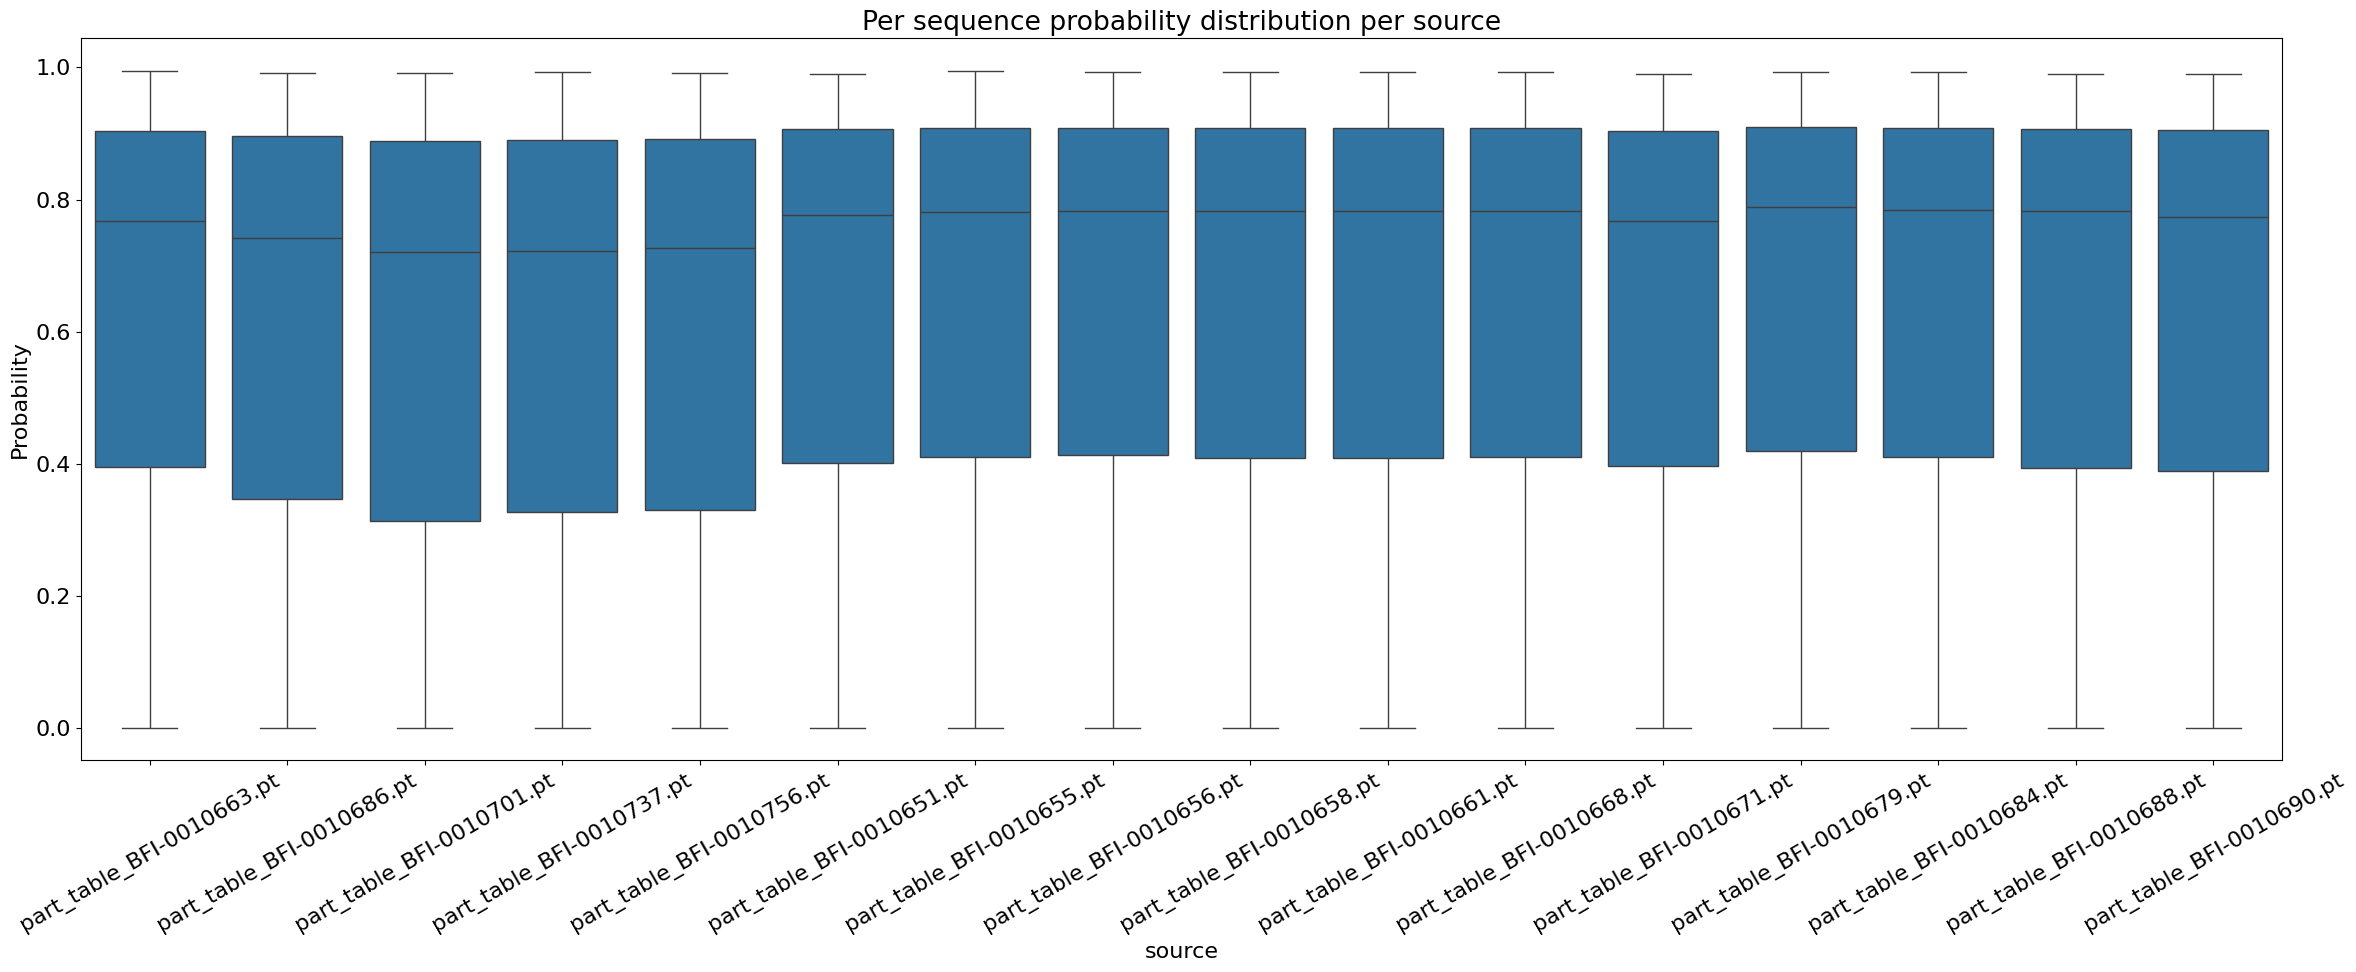

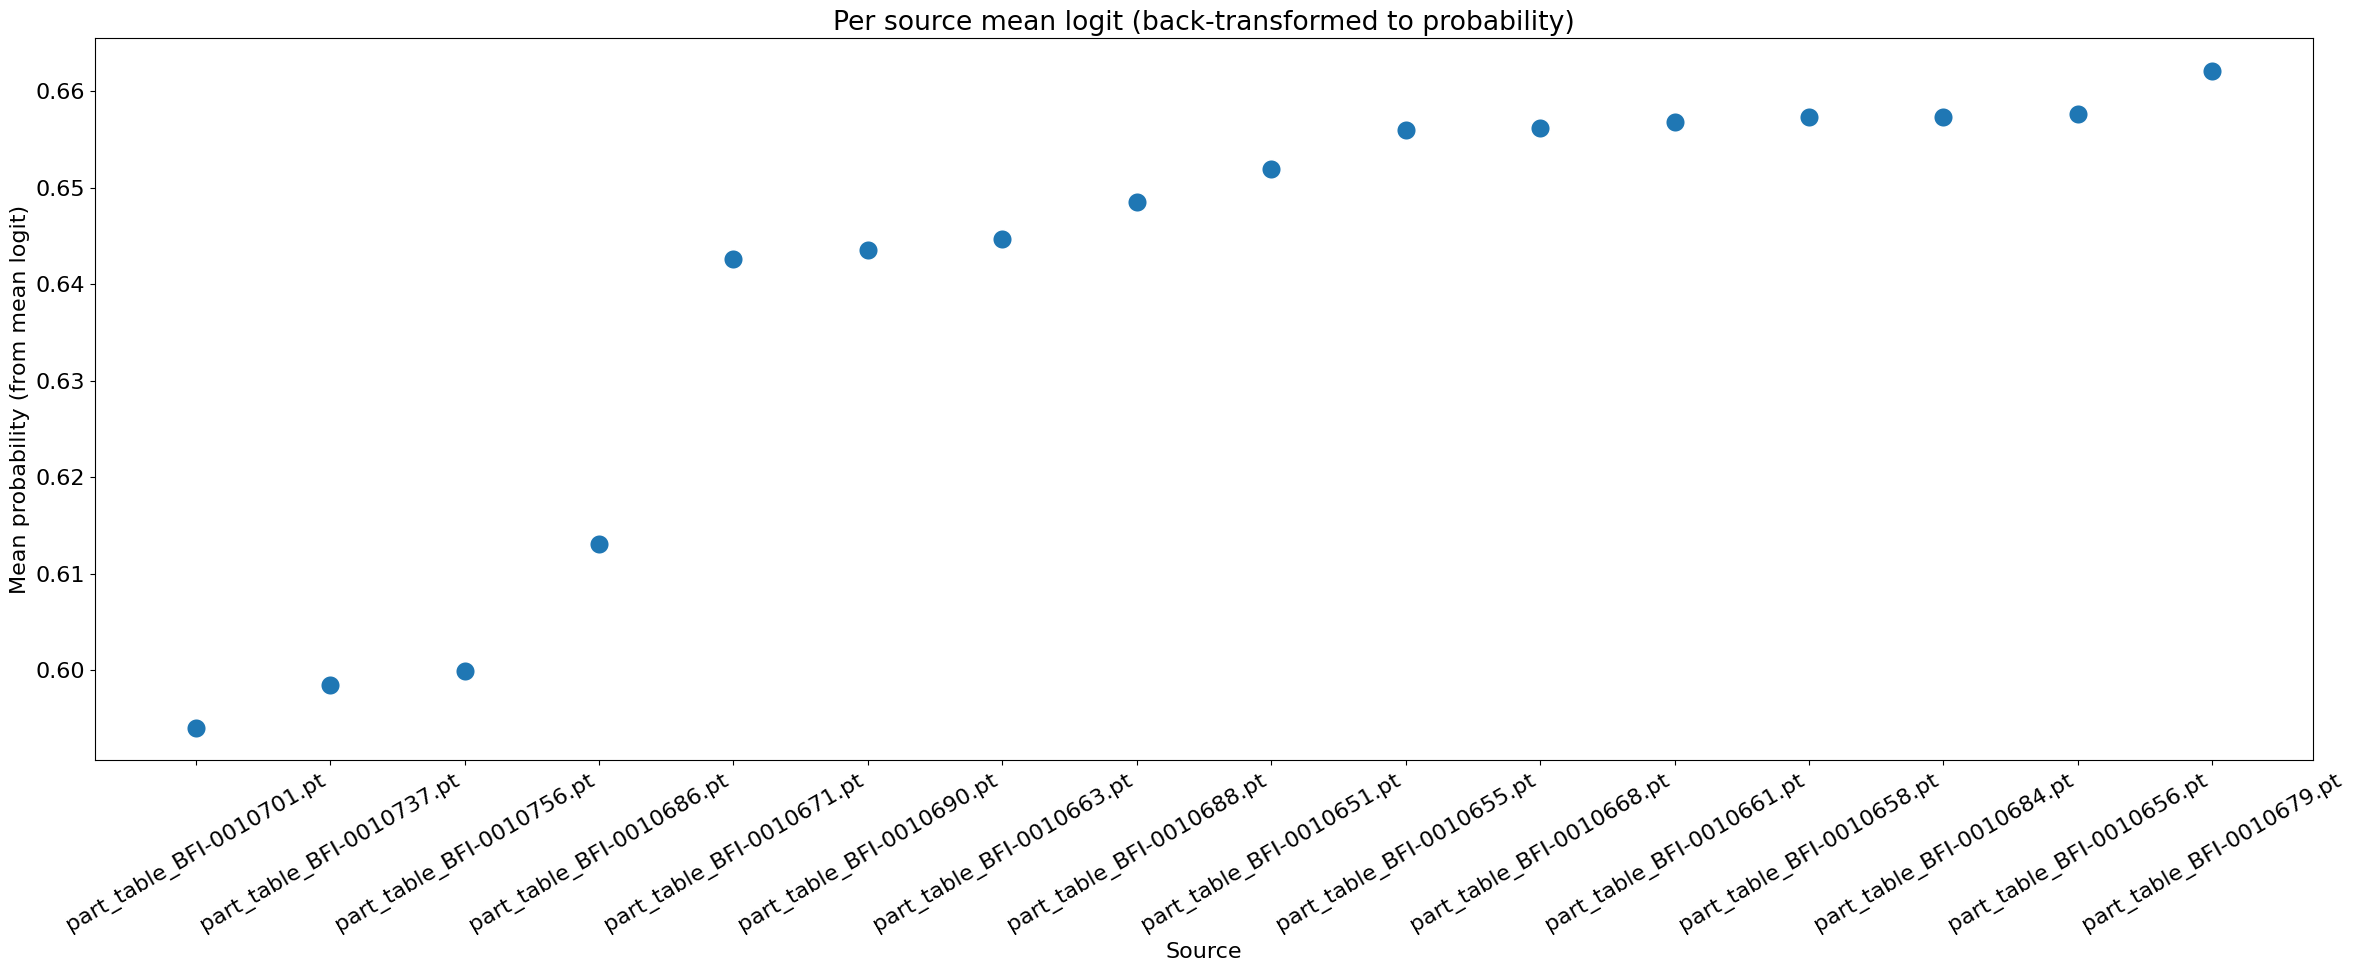

,source,inv_logit_mean
0,part_table_BFI-0010701.pt,0.594037
1,part_table_BFI-0010737.pt,0.598447
2,part_table_BFI-0010756.pt,0.599866
3,part_table_BFI-0010686.pt,0.613090
4,part_table_BFI-0010671.pt,0.642670
5,part_table_BFI-0010690.pt,0.643577
6,part_table_BFI-0010663.pt,0.644679
7,part_table_BFI-0010688.pt,0.648502
8,part_table_BFI-0010651.pt,0.651905
9,part_table_BFI-0010655.pt,0.655969


In [39]:
from tcrgnn import plot_inv_logit_per_source
summary_control = plot_inv_logit_per_source(control_df)
summary_control

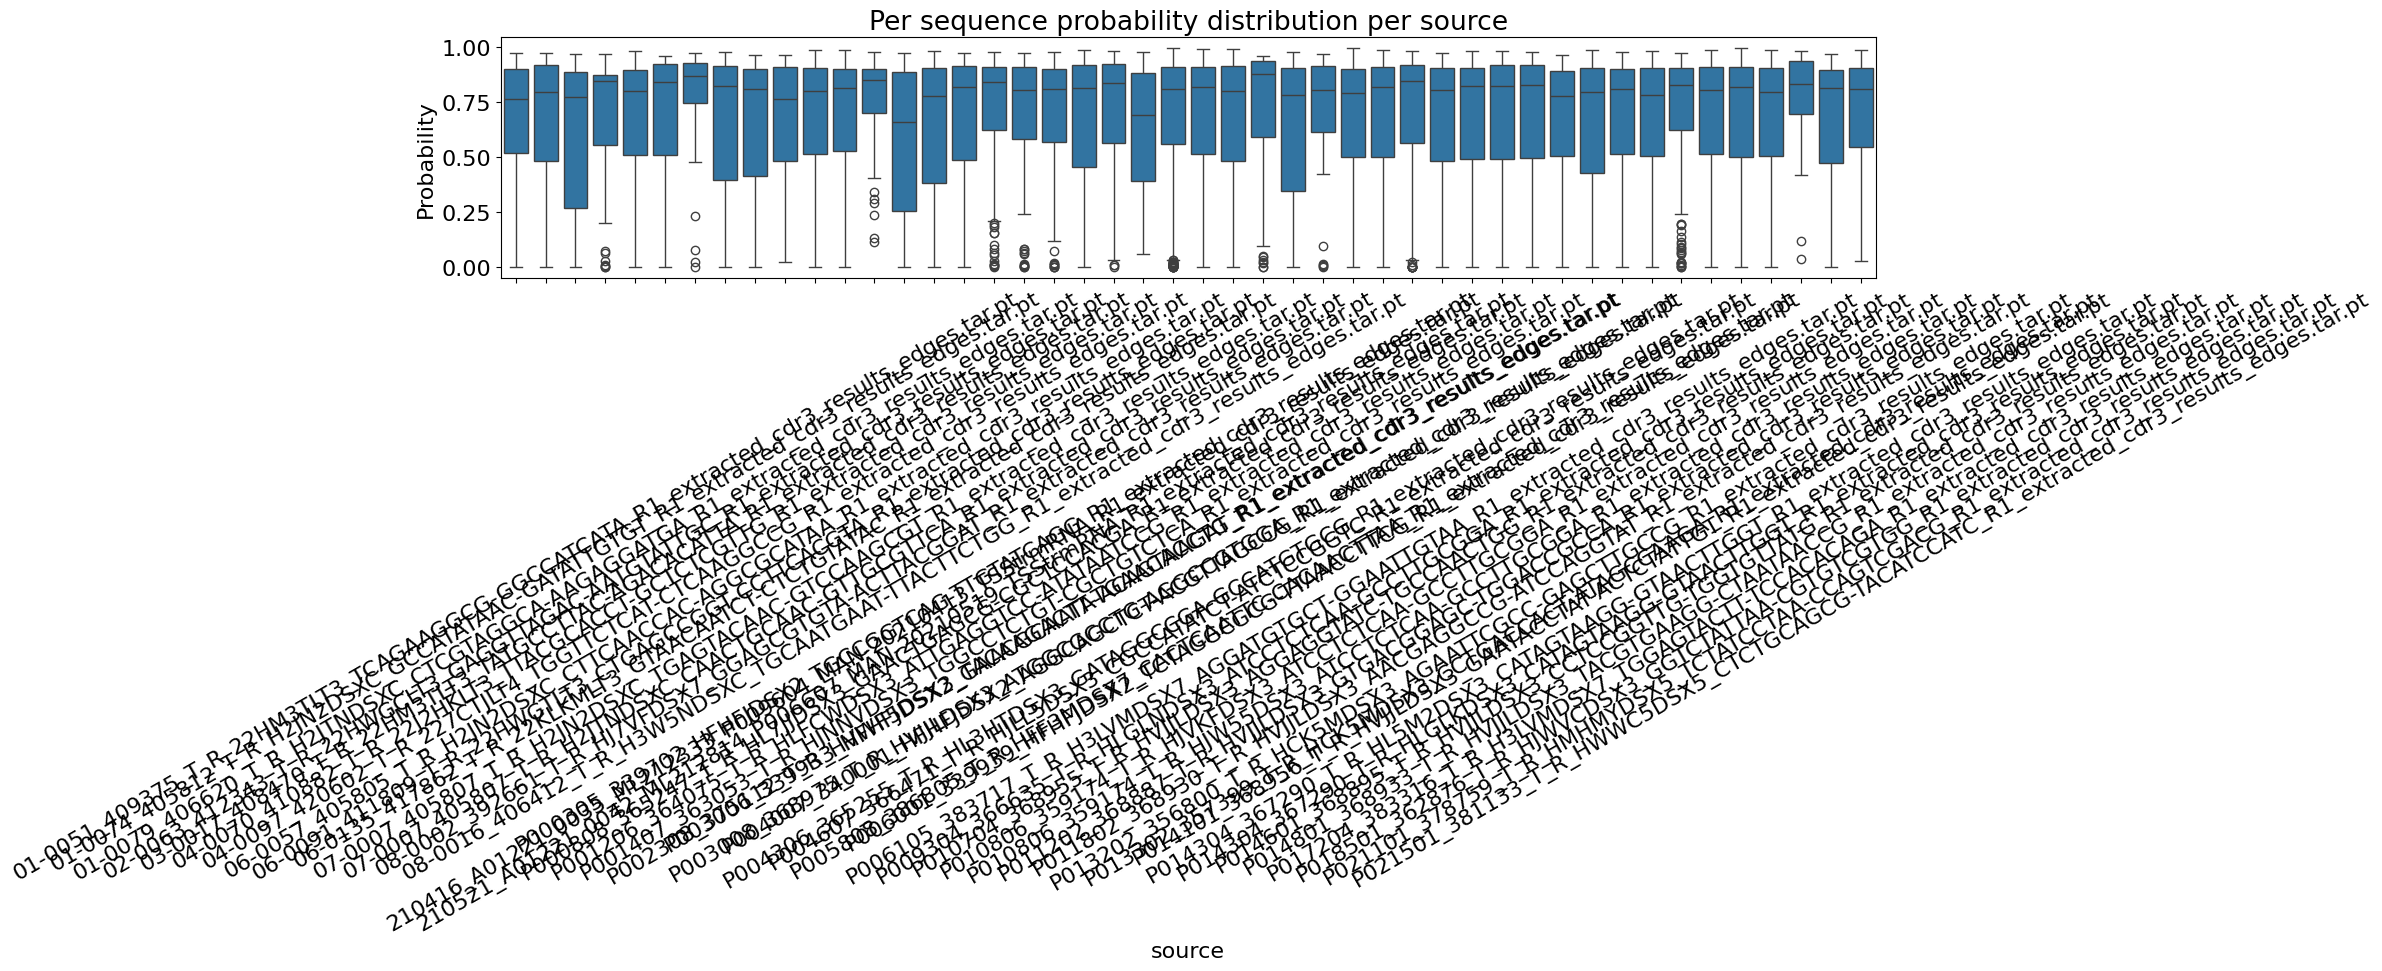

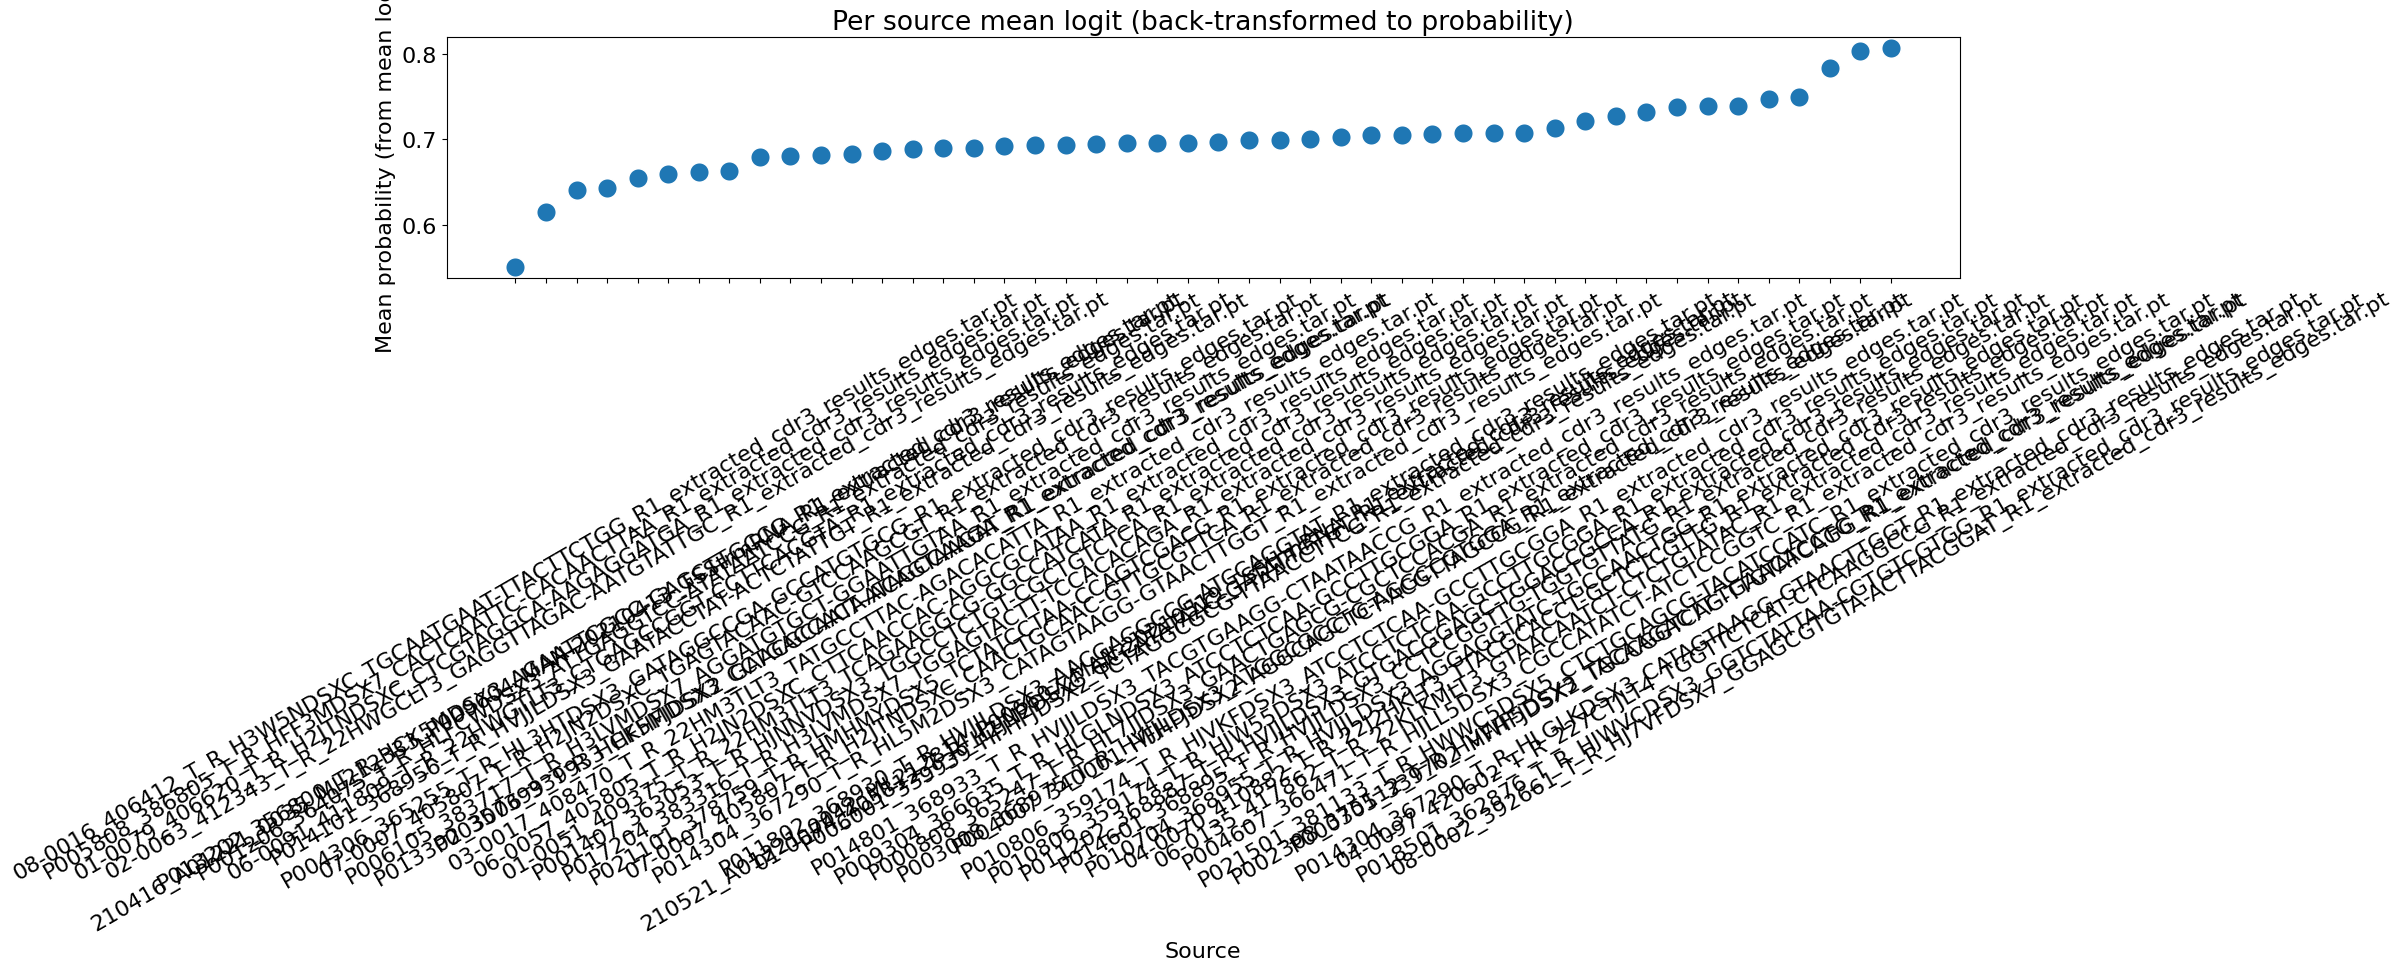

,source,inv_logit_mean
0,08-0016_406412_T_R_H3W5NDSXC_TGCAATGAAT-TTACTT...,0.549933
1,P005808_386805_T_R_HFF3MDSX7_CACTCAATTC-CACAAC...,0.615236
2,01-0079_406620_T_R_H2JTNDSXC_CTCGTAGGCA-AAGAGG...,0.640816
3,02-0063_412343_T_R_22HWGCLT3_GAGGTTAGAC-AATGTA...,0.642339
4,210416_A01221_0035_ML212333_P009604_MAN-202104...,0.654452
5,P013202_356800_T_R_HCK5MDSX3_AGAATTCGCC-GAGCTT...,0.659739
6,P001206_364075_T_R_HLFCWDSX3_ATTGAGGTCC-ATATAA...,0.662195
7,06-0091_411809_T_R_22HWGTLT3_CTGAGCCGGT-CCTTCA...,0.662343
8,P014101_368956_T_R_HVJJLDSX3_GAATACCTAT-ACTCTA...,0.678847
9,P004306_365255_T_R_HL3HTDSX3_GATAGGCCGA-GCCATG...,0.680421


In [40]:
summary_cancer = plot_inv_logit_per_source(cancer_df)
summary_cancer

In [41]:
control_df.groupby("source")["scores"].mean()

source
part_table_BFI-0010651.pt    0.639605
part_table_BFI-0010655.pt    0.643444
part_table_BFI-0010656.pt    0.645011
part_table_BFI-0010658.pt    0.644171
part_table_BFI-0010661.pt    0.644089
part_table_BFI-0010663.pt    0.635535
part_table_BFI-0010668.pt    0.643913
part_table_BFI-0010671.pt    0.635351
part_table_BFI-0010679.pt    0.648100
part_table_BFI-0010684.pt    0.644673
part_table_BFI-0010686.pt    0.615121
part_table_BFI-0010688.pt    0.638154
part_table_BFI-0010690.pt    0.635939
part_table_BFI-0010701.pt    0.600496
part_table_BFI-0010737.pt    0.603754
part_table_BFI-0010756.pt    0.605279
Name: scores, dtype: float64

In [28]:
cancer_df.groupby("source")["scores"].mean()

source
01-0051_409375_T_R_22HM3TLT3_TCAGAAGGCG-GGCCATCATA_R1_extracted_cdr3_results_edges.tar.pt            0.669006
01-0074_405812_T_R_H2JN2DSXC_GCCATATAAC-GATATTGTGT_R1_extracted_cdr3_results_edges.tar.pt            0.659500
01-0079_406620_T_R_H2JTNDSXC_CTCGTAGGCA-AAGAGGATGA_R1_extracted_cdr3_results_edges.tar.pt            0.617211
02-0063_412343_T_R_22HWGCLT3_GAGGTTAGAC-AATGTATTGC_R1_extracted_cdr3_results_edges.tar.pt            0.664211
03-0017_408470_T_R_22HM3TLT3_TATGCCTTAC-AGACACATTA_R1_extracted_cdr3_results_edges.tar.pt            0.665845
04-0070_410882_T_R_22J2HKLT3_TTACGCACCT-GCTCTCGTTG_R1_extracted_cdr3_results_edges.tar.pt            0.690471
04-0097_420602_T_R_227CTJLT4_TGGTTCTCAT-CTCAAGGCCG_R1_extracted_cdr3_results_edges.tar.pt            0.747301
06-0057_405805_T_R_H2JN2DSXC_CTTCAACCAC-AGGCGCATAA_R1_extracted_cdr3_results_edges.tar.pt            0.654319
06-0091_411809_T_R_22HWGTLT3_CTGAGCCGGT-CCTTCACGTA_R1_extracted_cdr3_results_edges.tar.pt            0.646190
06-

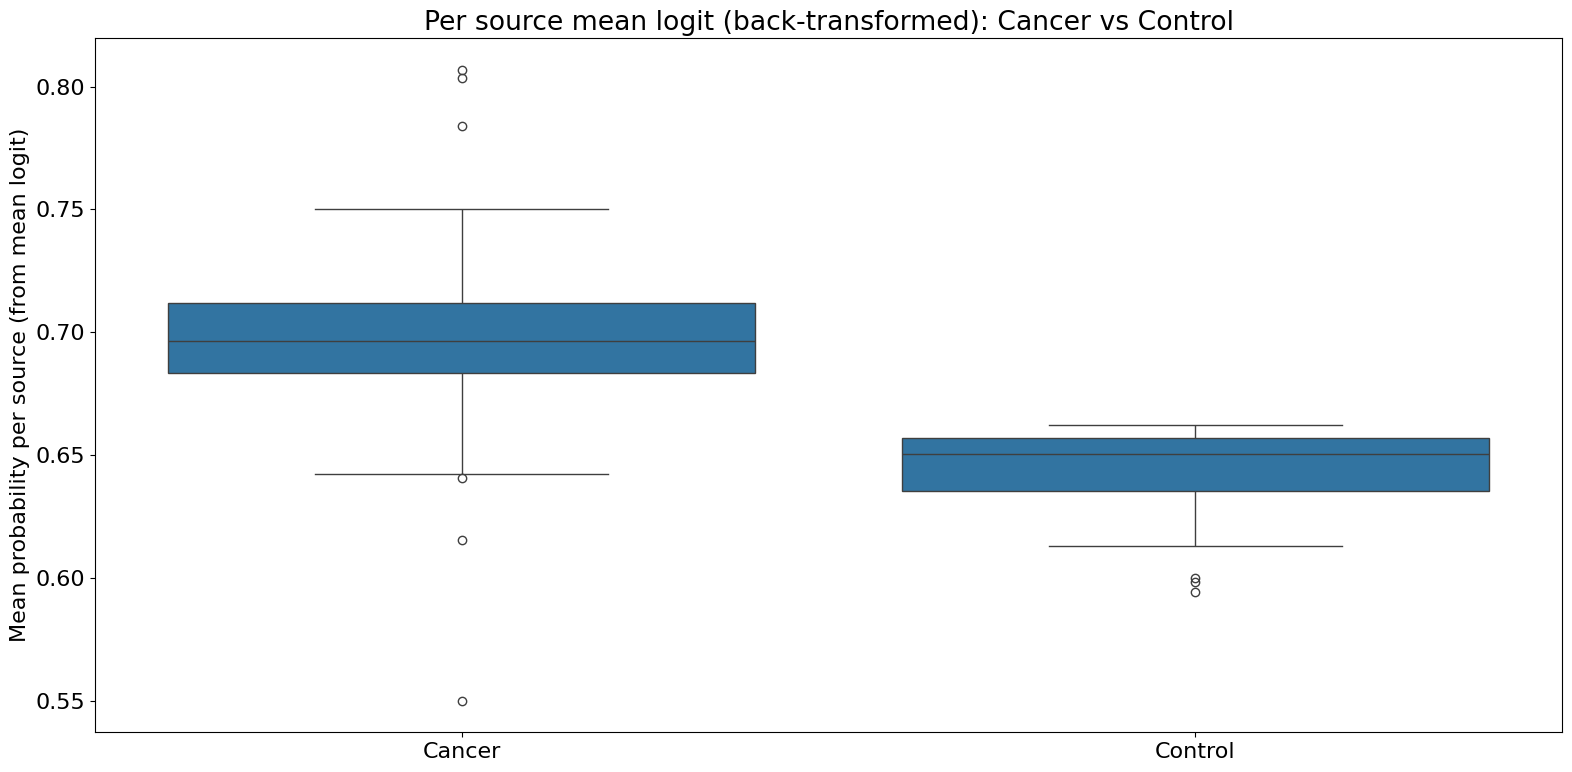

,source,group,inv_logit_mean
0,08-0002_392661_T_R_HJ7VFDSX7_GGAGCGTGTA-ACTTAC...,Cancer,0.806798
1,P018501_362876_T_R_HJWVCDSX3_GGTCTATTAA-CGTGTC...,Cancer,0.803307
2,04-0097_420602_T_R_227CTJLT4_TGGTTCTCAT-CTCAAG...,Cancer,0.783931
3,P014304_367290_T_R_HLGLKDSX3_CATAGTAAGG-GTAACT...,Cancer,0.750135
4,P000305_339702_HFHFJDSX2_TGCCGGTCAG-TTGTATCAGG...,Cancer,0.747380
...,...,...,...
57,part_table_BFI-0010671.pt,Control,0.642670
58,part_table_BFI-0010686.pt,Control,0.613090
59,part_table_BFI-0010756.pt,Control,0.599866
60,part_table_BFI-0010737.pt,Control,0.598447


In [42]:
from tcrgnn import plot_roc_from_summary,summarize_and_plot_inv_logit_means

# Now we want to compare between the cancer and control samples
summary_long,summary_wide = summarize_and_plot_inv_logit_means(cancer_df,control_df)
summary_long

AUPRC = 0.9767885862814628


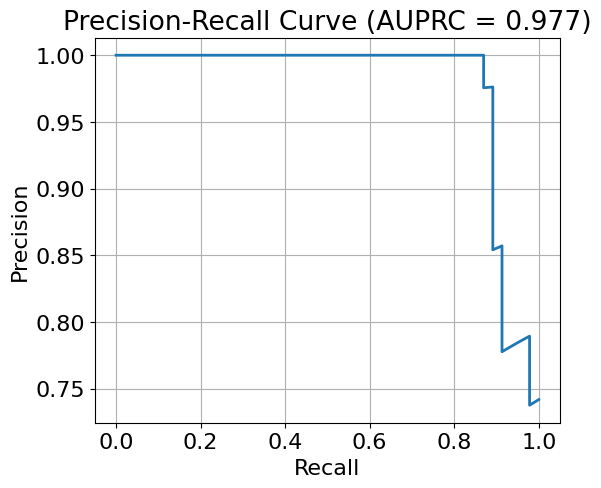

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# df must contain: df["group"], df["inv_logit_mean"]

# Convert group labels to binary target
summary_long["label"] = (summary_long["group"] == "Cancer").astype(int)

y_true = summary_long["label"].values
y_score = summary_long["inv_logit_mean"].values

# Compute Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_true, y_score)
auprc = average_precision_score(y_true, y_score)

print("AUPRC =", auprc)

# Plot
plt.figure(figsize=(6,5))
plt.plot(recall, precision, linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AUPRC = {auprc:.3f})")
plt.grid(True)
plt.show()


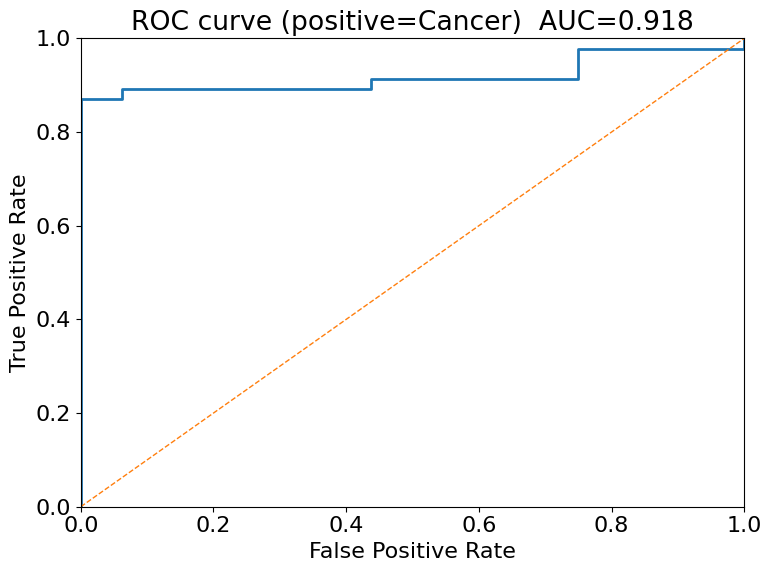

(       fpr       tpr  threshold
 0   0.0000  0.000000        inf
 1   0.0000  0.021739   0.806798
 2   0.0000  0.043478   0.803307
 3   0.0000  0.065217   0.783931
 4   0.0000  0.086957   0.750135
 ..     ...       ...        ...
 59  0.8750  0.978261   0.599866
 60  0.9375  0.978261   0.598447
 61  1.0000  0.978261   0.594037
 62  1.0000  1.000000   0.549933
 63  1.0000  1.000000       -inf
 
 [64 rows x 3 columns],
 0.9184782608695651)

In [44]:
from tcrgnn import plot_roc_from_summary

plot_roc_from_summary(summary_long)

In [23]:
# Compute ratio of means: Cancer mean / Control mean

# Make sure labels are 1 = cancer, 0 = control
cancer_mean = summary_long.loc[summary_long["label"] == 1, "inv_logit_mean"].mean()
control_mean = summary_long.loc[summary_long["label"] == 0, "inv_logit_mean"].mean()

ratio_of_means = cancer_mean / control_mean

print("Cancer mean:", cancer_mean)
print("Control mean:", control_mean)
print("Ratio of means:", ratio_of_means)


Cancer mean: 0.6992183970304838
Control mean: 0.6582396283352848
Ratio of means: 1.062255092114153
